In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv(r"C:\Users\HP\Documents\Sravya\excelr\Assignments\Basic stats - 1\Basic stats - 1\sales_data_with_discounts.csv")

# Display basic information and the first few rows
print("--- Dataset Summary Info ---")
df.info()
print("\n--- First 5 Rows ---")
df.head()

--- Dataset Summary Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               450 non-null    object 
 1   Day                450 non-null    object 
 2   SKU                450 non-null    object 
 3   City               450 non-null    object 
 4   Volume             450 non-null    int64  
 5   BU                 450 non-null    object 
 6   Brand              450 non-null    object 
 7   Model              450 non-null    object 
 8   Avg Price          450 non-null    int64  
 9   Total Sales Value  450 non-null    int64  
 10  Discount Rate (%)  450 non-null    float64
 11  Discount Amount    450 non-null    float64
 12  Net Sales Value    450 non-null    float64
dtypes: float64(3), int64(3), object(7)
memory usage: 45.8+ KB

--- First 5 Rows ---


,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [9]:
# Identify numerical columns automatically
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numerical Columns Identified:", numerical_cols)

# Calculate Mean, Median,Mode, and Standard Deviation
descriptive_stats = pd.DataFrame(index=['Mean', 'Median', 'Mode', 'Standard Deviation'])

for col in numerical_cols:
    # Mode can have multiple values, taking the first one
    mode_val = df[col].mode()[0] if not df[col].mode().empty else np.nan
    
    descriptive_stats[col] = [
        df[col].mean(),
        df[col].median(),
        mode_val,
        df[col].std()
    ]

# Display results
print("\n--- Descriptive Statistics Summary ---")
display(descriptive_stats)

print("\n--- Brief Interpretation ---")
print("- 'Volume' and 'Avg Price' indicate standard physical sales metrics.")
print("- 'Total Sales Value', 'Discount Amount', and 'Net Sales Value' capture financial performance metrics.")
print("- Differences between Mean and Median indicate potential skewness in distributions (e.g., higher Means suggest right skew).")

Numerical Columns Identified: ['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)', 'Discount Amount', 'Net Sales Value']

--- Descriptive Statistics Summary ---


,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
Mean,5.066667,10453.433333,33812.835556,15.155242,3346.499424,30466.336131
Median,4.000000,1450.000000,5700.000000,16.577766,988.933733,4677.788059
Mode,3.000000,400.000000,24300.000000,5.007822,69.177942,326.974801
Standard Deviation,4.231602,18079.904840,50535.074173,4.220602,4509.902963,46358.656624



--- Brief Interpretation ---
- 'Volume' and 'Avg Price' indicate standard physical sales metrics.
- 'Total Sales Value', 'Discount Amount', and 'Net Sales Value' capture financial performance metrics.
- Differences between Mean and Median indicate potential skewness in distributions (e.g., higher Means suggest right skew).


--- Generating Histograms ---


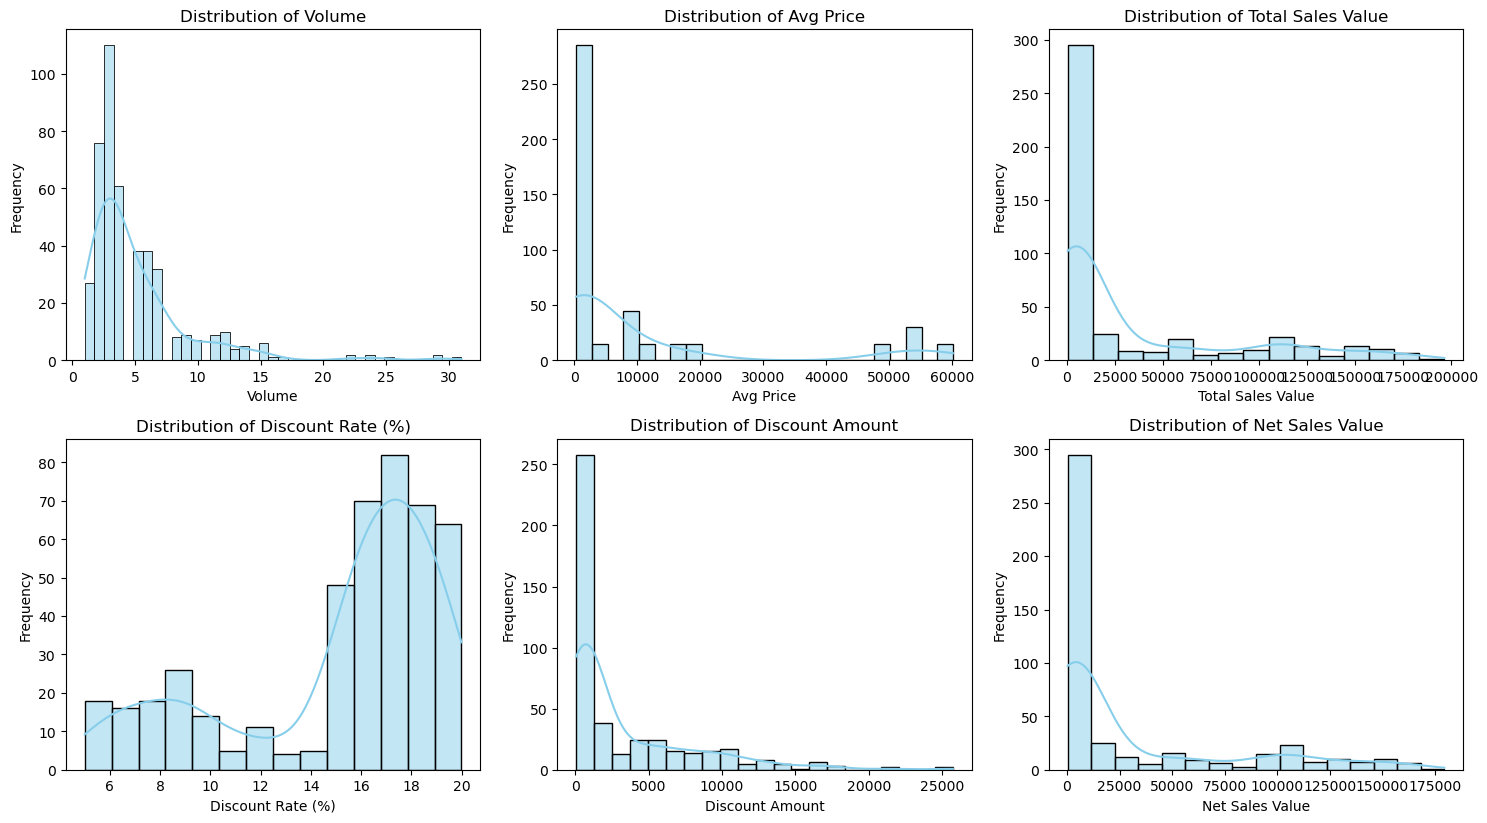

--- Generating Boxplots ---


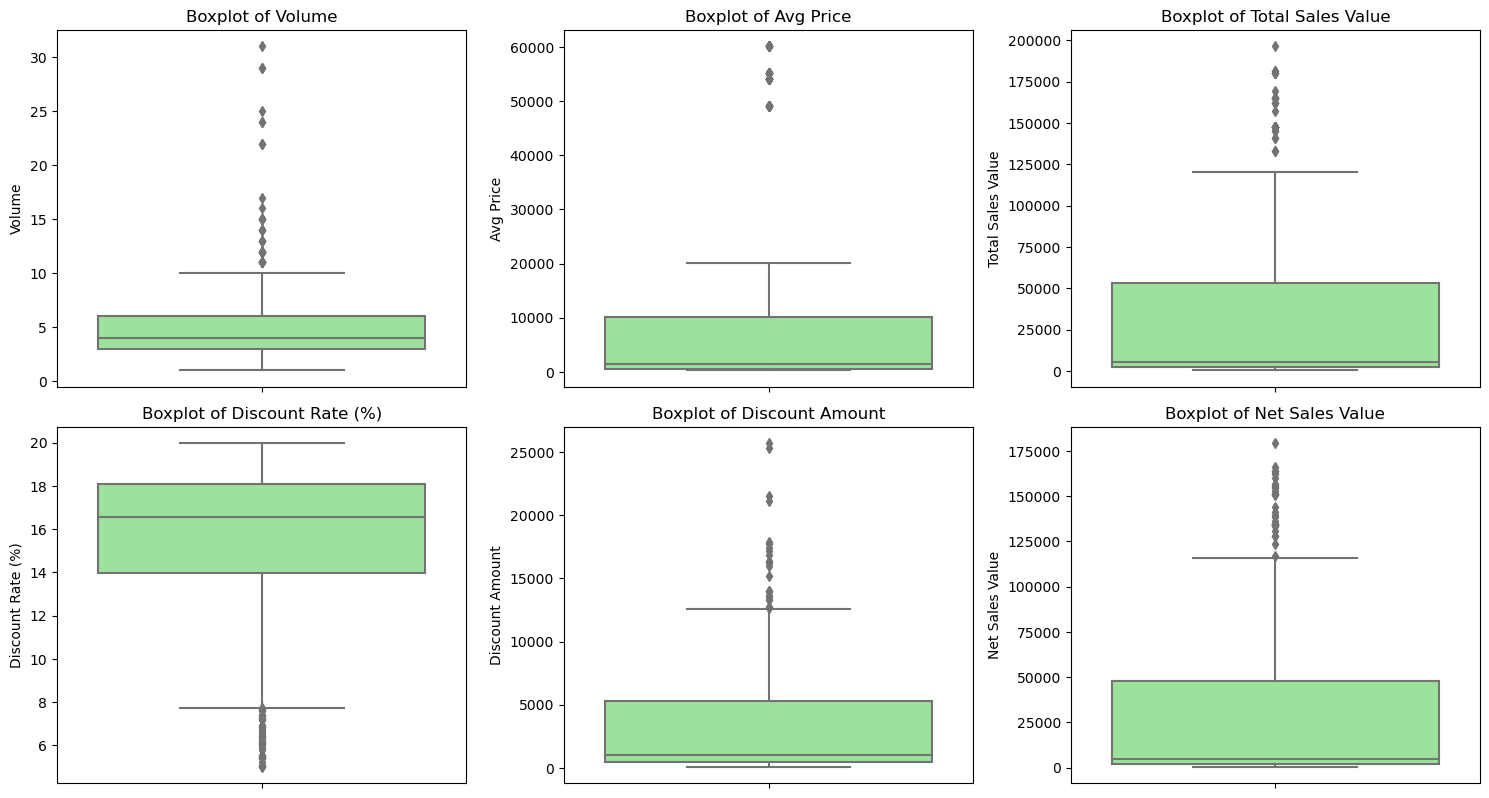


--- Visualization Inferences ---
- Skewness: Columns like 'Total Sales Value' and 'Discount Amount' typically show significant right skew due to high-value transactions.
- Outliers: The boxplots explicitly highlight values extending beyond the upper whiskers as statistical outliers, which require careful observation during modelling.


In [12]:
# 1. Histograms for Numerical Columns
print("--- Generating Histograms ---")
plt.figure(figsize=(15, 12))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# 2. Boxplots for Numerical Columns
print("--- Generating Boxplots ---")
plt.figure(figsize=(15, 12))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

print("\n--- Visualization Inferences ---")
print("- Skewness: Columns like 'Total Sales Value' and 'Discount Amount' typically show significant right skew due to high-value transactions.")
print("- Outliers: The boxplots explicitly highlight values extending beyond the upper whiskers as statistical outliers, which require careful observation during modelling.")

Key Categorical Columns Identified: ['Day', 'City', 'BU', 'Brand']


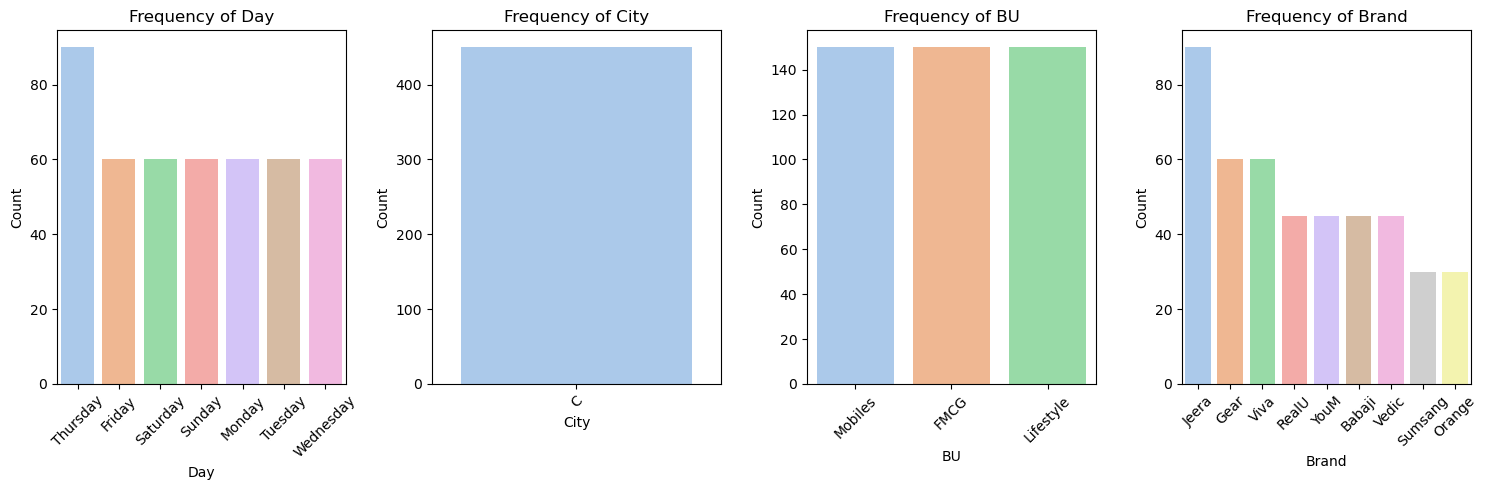


--- Categorical Insights ---
- It highlights which business units (BU), regions/cities, and days bring in the highest transaction frequencies.


In [10]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
# Filter out high-cardinality unique IDs or dates if unnecessary, but let's look at key ones like 'Day', 'City', 'BU', 'Brand'
focus_categorical = [col for col in categorical_cols if col not in ['Date', 'Model', 'SKU']]
print("Key Categorical Columns Identified:", focus_categorical)

# Generate Bar Charts
plt.figure(figsize=(15, 5))
for i, col in enumerate(focus_categorical, 1):
    plt.subplot(1, len(focus_categorical), i)
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='pastel')
    plt.title(f'Frequency of {col}')
    plt.xticks(rotation=45)
    plt.xlabel(col)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

print("\n--- Categorical Insights ---")
print("- It highlights which business units (BU), regions/cities, and days bring in the highest transaction frequencies.")

# Standardization of Numerical Variables

In [ ]:
print("--- Standardization (Z-score Normalization) ---")
print("Concept: Standardization shifts distribution to have a mean of 0 and a standard deviation of 1 using z = (x - mu) / sigma.")

# Creating a copy to observe before/after distributions
df_scaled = df.copy()


for col in numerical_cols:
    mu = df[col].mean()
    sigma = df[col].std()
    df_scaled[col] = (df[col] - mu) / sigma

# Showcase Before & After Distributions
print("\n--- Summary Statistics Comparison ---")
for col in numerical_cols[:3]: # Sample 3 columns to save space
    print(f"\n[{col}] Original Mean: {df[col].mean():.4f} | Std: {df[col].std():.4f}")
    print(f"[{col}] Standardized Mean: {df_scaled[col].mean():.4f} | Std: {df_scaled[col].std():.4f}")

# Plotting sample comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df[numerical_cols[0]], ax=axes[0], kde=True, color='blue').set(title=f'Original {numerical_cols[0]}')
sns.histplot(df_scaled[numerical_cols[0]], ax=axes[1], kde=True, color='orange').set(title=f'Standardized {numerical_cols[0]}')
plt.show()

In [8]:
print("--- One-Hot Encoding ---")

# Let's apply dummy variable conversion to key categorical attributes
df_processed = pd.get_dummies(df_scaled, columns=focus_categorical, drop_first=False)

# Display a portion of the final transformed dataset
print("\n--- Tail Portion of Transformed Dataset Column Headers ---")
display(df_processed.head())
print("Processed Dataset Shape:", df_processed.shape)

--- One-Hot Encoding ---

--- Tail Portion of Transformed Dataset Column Headers ---


,Date,SKU,Volume,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value,Day_Friday,...,BU_Mobiles,Brand_Babaji,Brand_Gear,Brand_Jeera,Brand_Orange,Brand_RealU,Brand_Sumsang,Brand_Vedic,Brand_Viva,Brand_YouM
0,01-04-2021,M01,2.347417,RU-10,0.091072,2.922469,-0.829365,3.948422,2.801638,False,...,True,False,False,False,False,True,False,False,False,False
1,01-04-2021,M02,1.165831,RU-9 Plus,-0.019548,1.329516,-0.851714,1.846958,1.269613,False,...,True,False,False,False,False,True,False,False,False,False
2,01-04-2021,M03,0.456880,YM-99,0.312312,1.561038,-1.350129,1.621190,1.543957,False,...,True,False,False,False,False,False,False,False,False,True
3,01-04-2021,M04,0.220563,YM-99 Plus,0.533552,1.717365,-1.947555,1.112568,1.763847,False,...,True,False,False,False,False,False,False,False,False,True
4,01-04-2021,M05,-0.488389,YM-98,-0.130168,-0.188242,0.672990,0.227598,-0.227342,False,...,True,False,False,False,False,False,False,False,False,True


Processed Dataset Shape: (450, 29)
